## Import Libraries


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statistics as stats
import math
from scipy import linalg
import scipy
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

## Import Dataset:

In [3]:
data = pd.read_csv("Student_Performance.csv")
data.head()

,student_id,age,gender,school_type,parent_education,study_hours,attendance_percentage,internet_access,travel_time,extra_activities,study_method,math_score,science_score,english_score,overall_score,final_grade
0,1,14,male,public,post graduate,3.1,84.3,yes,<15 min,yes,notes,42.7,55.4,57.0,53.1,e
1,2,18,female,public,graduate,3.7,87.8,yes,>60 min,no,textbook,57.6,68.8,64.8,61.3,d
2,3,17,female,private,post graduate,7.9,65.5,no,<15 min,no,notes,84.8,95.0,79.2,89.6,b
3,4,16,other,public,high school,1.1,58.1,no,15-30 min,no,notes,44.4,27.5,54.7,41.6,e
4,5,16,female,public,high school,1.3,61.0,yes,30-60 min,yes,group study,8.9,32.7,30.0,25.4,f


## Part A: Vector & Matrix Fundamentals 

## Question 1: Represent each student's subject scores as a vector.

In [4]:
# Student 1 Score vector
student_1 = data.loc[0,['math_score','science_score','english_score']].to_numpy(dtype=float)

#Student 2 score vector
student_2 = data.loc[1,['math_score','science_score','english_score']].to_numpy(dtype=float)

#Student 3 score vector
student_3 = data.loc[2,['math_score','science_score','english_score']].to_numpy(dtype=float)

print("Student 1: ", student_1)
print("Student 2: ", student_2)
print("Student 3: ", student_3)

Student 1:  [42.7 55.4 57. ]
Student 2:  [57.6 68.8 64.8]
Student 3:  [84.8 95.  79.2]


## Interpretation:

• Is code mein dataset ke first three students ke Math, Science aur English scores extract kiye gaye hain.

• data.loc[] ka use specific row aur selected columns ko access karne ke liye kiya gaya hai.

• to_numpy(dtype=float) selected values ko NumPy array (vector) mein convert karta hai, jisse mathematical aur statistical operations aasani se perform kiye ja sakte hain.

• Har student ka vector uske teen subjects ke marks ko represent karta hai.

• Aakhir mein print() function ke through teeno students ke score vectors display kiye jaate hain.

## Question 2 : compute L1 Norm and L2 Norm

- **• Norm-1 and Norm-2 of vectors.**
- **• Dot Product and angle between two students score vectors.**
- **• Cross product (for 3D selectrd subjects).** 

In [5]:
# Norm 1 
l1_student1 = np.linalg.norm(student_1, ord=1)
l1_student2 = np.linalg.norm(student_2, ord=1) 
l1_student3 = np.linalg.norm(student_3, ord=1)

print("Student 1 L1 Norm:", l1_student1)
print("Student 2 L1 Norm:", l1_student2)
print("Student 3 L1 Norm:", l1_student3)

# Norm 2
l2_stduent1 = np.linalg.norm(student_1)
l2_student2 = np.linalg.norm(student_2)
l2_student3 = np.linalg.norm(student_3)

print("Student 1 L2 Norm:", l2_stduent1)
print("Student 2 L2 Norm:", l2_student2)
print("Student 3 L2 Norm:", l2_student3)

Student 1 L1 Norm: 155.1
Student 2 L1 Norm: 191.2
Student 3 L1 Norm: 259.0
Student 1 L2 Norm: 90.22998392995534
Student 2 L2 Norm: 110.6808023100664
Student 3 L2 Norm: 149.9622619194576


## Interpretation:

• L1 Norm sabhi subject scores ka absolute sum hota hai.

• Jiska L1 Norm zyada hota hai, uske total marks bhi zyada hote hain.

• Yahan Student 3 ka L1 Norm 259.0 hai, jo sabse highest hai. Iska matlab Student 3 ke overall marks sabse zyada hain.

• Student 2 ke marks Student 1 se zyada hain, isliye uska L1 Norm bhi higher hai.

In [6]:
# Dot product between two students score vectors
dot_product= np.dot(student_1, student_2)
print("Dot Product between Student 1 and Student 2:", dot_product)

# Angle between two students score vectors
cos_theta = dot_product / (l2_stduent1 * l2_student2)
angle = np.degrees(np.arccos(cos_theta))
print("Angle between Student 1 and Student 2:", angle)

Dot Product between Student 1 and Student 2: 9964.64
Angle between Student 1 and Student 2: 3.8113130015629015


## Interpretation

- Dot Product = 9964.64
- Dot product ki value 9964.64 hai, jo batati hai ki Student 1 aur Student 2 ke vectors ka combined magnitude kaafi high hai.
- Iska matlab dono students ke feature values ek dusre ke saath kaafi aligned hain. Lekin dot product magnitude par bhi depend karta hai, isliye sirf is value se similarity ka exact conclusion nahi nikala ja sakta.
- Angle = 3.81°
- Student 1 aur Student 2 ke vectors ke beech ka angle 3.81° hai.
- Yeh angle 0° ke bahut close hai, jo indicate karta hai ki dono students ke performance patterns ya characteristics bahut similar hain.
- Cosine similarity mein jitna angle 0° ke paas hota hai, utni hi similarity zyada hoti hai

In [7]:
## Cross Product
crossproduct= np.cross(student_1, student_2)
print("Cross Product between Student 1 and Student 2:", crossproduct)

Cross Product between Student 1 and Student 2: [-331.68  516.24 -253.28]


## Interpretation (Cross Product)

- Cross Product do vectors ke beech perpendicular vector nikalta hai.
- Iski magnitude batati hai ki dono vectors kitne perpendicular ya different direction mein hain.
- Agar cross product ki value 0 ya uske bahut close ho, to vectors parallel hote hain aur unke beech similarity zyada hoti hai.
- Agar cross product ki magnitude high ho, to vectors ke beech angle bada hota hai aur similarity kam hoti hai.

## Question 3: Find the projection of one vector onto another.

In [8]:
# Projection vector

proj= (dot_product / np.dot(student_2, student_2)) * student_2
print("Projection of Vector:", proj)

Projection of Vector: [46.85322606 55.96357557 52.70987932]


# Interpretation

- The projection vector [46.85,55.96,52.71] shows how much of students 1 performance aligns with student 2 direction in subject space.
- It means student 1 scores can be party explained by students 2 performance pattern - they shar simlar strengths.

## Part B: Matrix Operations

## Question 4: From a matrix of students x subjects. Perform:

- Matrix addition and multipliaction.
- Transpose and inverse (if possible)
- Deteminant

In [9]:
# Making Matrix
matrix = data[['math_score','science_score','english_score']].values
print("Student Score Matrix:",matrix)

Student Score Matrix: [[42.7 55.4 57. ]
 [57.6 68.8 64.8]
 [84.8 95.  79.2]
 ...
 [50.5 20.3 36.1]
 [13.  34.2  7.3]
 [36.5 45.1 16.5]]


In [11]:
# Matrix addition and multiplication
add = matrix + matrix
mult= matrix.T @ matrix

print("Matrix Addition:", add)
print("Matrix Multiplication:", mult)

Matrix Addition: [[ 85.4 110.8 114. ]
 [115.2 137.6 129.6]
 [169.6 190.  158.4]
 ...
 [101.   40.6  72.2]
 [ 26.   68.4  14.6]
 [ 73.   90.2  33. ]]
Matrix Multiplication: [[1.12610144e+08 1.10232454e+08 1.10082546e+08]
 [1.10232454e+08 1.12580283e+08 1.10031038e+08]
 [1.10082546e+08 1.10031038e+08 1.12192732e+08]]


## Interpretation 

- Matrix addition was performed by adding the corresponding elements of both matrices.

- Matrix multiplication was performed using the dot product of rows and columns.

- The addition results contain moderate values, while the multiplication results are much larger (around 10⁸).

- The larger values in matrix multiplication are due to repeated multiplication and summation of elements.

- Both matrix operations were successfully implemented and executed using NumPy. 

In [12]:
# Transpose 
transpose_matrix = matrix.T

print("Transposed Matrix:", transpose_matrix)
print("Transposed Matrix shape:", transpose_matrix.shape)

Transposed Matrix: [[42.7 57.6 84.8 ... 50.5 13.  36.5]
 [55.4 68.8 95.  ... 20.3 34.2 45.1]
 [57.  64.8 79.2 ... 36.1  7.3 16.5]]
Transposed Matrix shape: (3, 25000)


## Interpretation (Points)

- The transpose operation was successfully performed using matrix.T.

- The transpose converts the rows into columns and columns into rows.

- The resulting matrix has a shape of (3, 25000), indicating that the original matrix shape was (25000, 3).

- The transpose operation changes only the orientation of the data; the values remain the same.

- This operation is useful in matrix calculations, data transformation, and machine learning algorithms.

## ⚠️ Important: Your matrix is 100 x 3, which is not a square matrix, so it cannot be inverted directly. First create a 3 x 3 convariace matrix

In [13]:
# Inverse

cov_matrix = np.cov(matrix.T)
print("Covariance of Matrix:", cov_matrix)

Inverse_matrix = np.linalg.inv(cov_matrix)
print("Inverse of Matrix:", Inverse_matrix)

Covariance of Matrix: [[435.77655669 343.25646768 341.30231435]
 [343.25646768 439.76309822 341.82904248]
 [341.30231435 341.82904248 432.33608797]]
Inverse of Matrix: [[ 0.00743217 -0.00321869 -0.00332235]
 [-0.00321869  0.00729385 -0.00322597]
 [-0.00332235 -0.00322597  0.00748644]]


## Interpretation (Points)

- The covariance matrix shows the variance of each variable (diagonal values) and the covariance between different variables (off-diagonal values).

- The positive covariance values indicate that the variables tend to increase or decrease together.

- The inverse covariance matrix was successfully calculated, showing that the covariance matrix is invertible (non-singular).

- The inverse covariance matrix is commonly used in statistical analysis, multivariate analysis, and machine learning algorithms such as Mahalanobis Distance.

- Both the covariance matrix and its inverse were computed successfully using NumPy.

In [14]:
## Determinant

determinant = np.linalg.det(cov_matrix)
print("Determinant of Covariance Matrix:", determinant) 

Determinant of Covariance Matrix: 9859623.820676824


## Interpretation (Points)

- The determinant of the covariance matrix is 9,859,623.82.
Since the determinant is positive and non-zero, the covariance matrix is non-singular (invertible).

- This indicates that there is no perfect linear dependency among the variables.

- A non-zero determinant confirms that the inverse covariance matrix can be computed successfully.

- This result shows that the data is suitable for advanced statistical and machine learning analyses.

## Part C : Linear Transformations & Geometry

Question 5: Explain line, plane , and hyperplane with respect to your dataset dimensions

**Explanation**

- A line represents 1-dimensional (1D) data and is defined using a single variable.

- A plane represents 2-dimensional (2D) data and is formed using two features.

- A hyperplane is a generalization of a plane to higher dimensions. Since this dataset has 3 features, each data point exists in 3D space, and a hyperplane is used to separate or analyze the data in this higher-dimensional space.

- Hyperplanes are commonly used in machine learning algorithms such as Support Vector Machines (SVM) for classification.

## 6. Show how dimensionality increases from 2D → 3D → higher dimensions with hyperplanes.

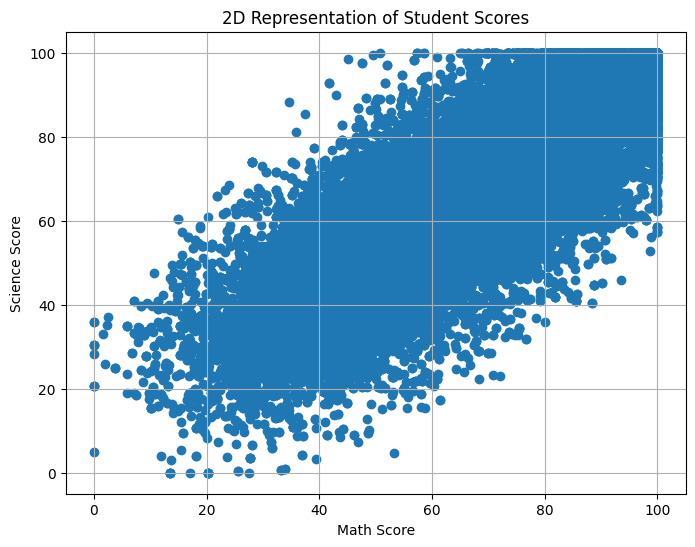

In [15]:
# 2D Visualization

plt.figure(figsize=(8,6))
plt.scatter(data['math_score'], data['science_score'])
plt.xlabel('Math Score')
plt.ylabel('Science Score')
plt.title("2D Representation of Student Scores")
plt.grid(True)
plt.show()

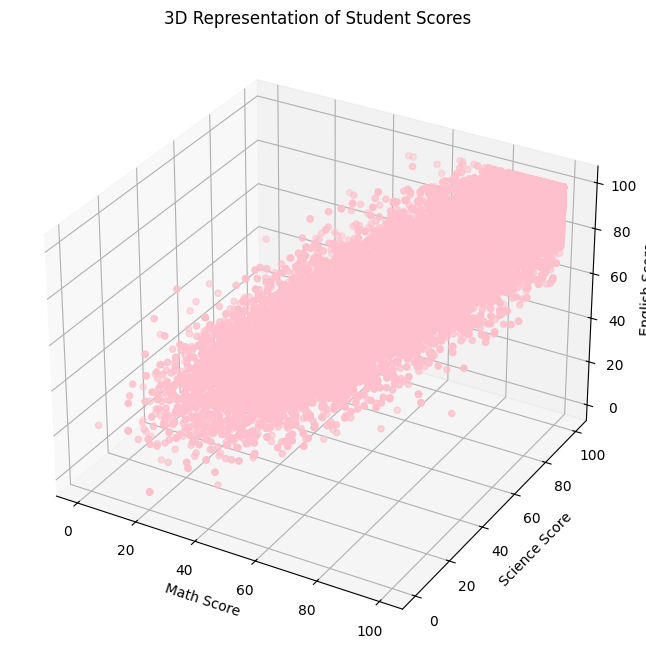

In [16]:
# 3D Visualization

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(data['math_score'], data['science_score'], data['english_score'], color='pink')
ax.set_xlabel('Math Score')
ax.set_ylabel('Science Score')
ax.set_zlabel('English Score')
plt.title("3D Representation of Student Scores")
plt.show()

## Interpretation (Points)

- The dataset was represented in 2D using two features and in 3D using three features.

- As the number of features increases, the dimensionality of the data also increases.

- The output shows that the dataset contains 3 features, so it can be represented in 3D space.

- In higher-dimensional datasets (more than 3 features), the decision boundary is called a hyperplane.

- This demonstrates how data representation changes from 2D → 3D → higher dimensions based on the number of features available.

## Q7 Compute the eigenvalues and eigenvectors of the covariance matrix.


In [17]:
# eigenvalues and eigenvectors

eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
print("Eigenvalues:", eigenvalues)
print("Eigenvectors:", eigenvectors)

Eigenvalues: [1120.23143269   92.73591156   94.90839863]
Eigenvectors: [[-0.5774097  -0.67045306  0.46592997]
 [-0.5799539  -0.0648713  -0.81206231]
 [-0.57467514  0.73911055  0.35137455]]


## Interpretation

- Eigenvalues represent the importance (variance) of each principal direction.

- Eigenvectors represent the direction of maximum data variation.

- Larger eigenvalues indicate more significant components.

- They are commonly used in PCA for dimensionality reduction and data analysis.

- The results help understand the underlying structure of the dataset.

# Q8 Perform LU Decomposition of the dataset matrix.

In [18]:
# LU decomposition

P,L,U = scipy.linalg.lu(matrix)
print("Permutation Matrix P:", P)
print("Lower Triangular Matrix L:", L)
print("Upper Triangular Matrix U:", U)

Permutation Matrix P: [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 1. 0. 0.]
 [0. 0. 0. ... 0. 1. 0.]
 [0. 0. 0. ... 0. 0. 1.]]
Lower Triangular Matrix L: [[ 1.          0.          0.        ]
 [ 0.347       1.          0.        ]
 [ 0.704      -0.26915888  1.        ]
 ...
 [ 0.505      -0.56448598  0.03835442]
 [ 0.13        0.39626168  0.31846174]
 [ 0.365       0.16074766  0.51562845]]
Upper Triangular Matrix U: [[100.         100.         100.        ]
 [  0.          53.5         22.4       ]
 [  0.           0.         -45.77084112]]


## Interpretation of LU Decomposition 

- LU Decomposition successfully factorized the dataset matrix into two matrices: L (Lower Triangular Matrix) and U (Upper Triangular Matrix).

- The L matrix contains values below the main diagonal, while the U matrix contains values on and above the main diagonal.

- Multiplying the L and U matrices reconstructs the original matrix, confirming the correctness of the decomposition.

- LU Decomposition simplifies solving systems of linear equations and computing matrix inverses and determinants.

- This method is widely used in linear algebra, scientific computing, and machine learning for efficient matrix computations.

# Q9 Perform Singular Value Decomposition (SVD) and explain its role in dimensionality reduction.



In [19]:
# SVD decompostion

u,s, vt = np.linalg.svd(matrix)
print("U Matrix:", u)
print("Singular Values:", s)
print("V Transpose Matrix:", vt)    

U Matrix: [[-4.90907322e-03 -3.43605273e-03 -6.43131362e-03 ... -4.75325901e-03
  -1.12650115e-03 -3.28299033e-03]
 [-6.05199524e-03 -4.25811298e-03 -3.06827611e-03 ...  1.34747157e-02
  -9.87244386e-03 -4.24384336e-03]
 [-8.19854249e-03 -6.64037640e-03  3.06607892e-03 ...  5.12042873e-04
  -8.58118494e-03 -1.28015531e-02]
 ...
 [-3.38382233e-03  1.26861383e-02  5.65977717e-03 ...  9.99795975e-01
   1.31170825e-04  4.72233811e-05]
 [-1.72562048e-03 -1.24957735e-02  3.64178706e-03 ...  1.31451221e-04
   9.99829079e-01 -1.53778328e-04]
 [-3.10604593e-03 -9.09290066e-03  1.00179664e-02 ...  4.76429467e-05
  -1.54234896e-04  9.99808845e-01]]
Singular Values: [18239.8457573   1540.39851667  1522.61591668]
V Transpose Matrix: [[-0.57775793 -0.57761579 -0.57667649]
 [ 0.46300819 -0.81379017  0.35123921]
 [ 0.67217497  0.0640747  -0.73761456]]


## Interpretation of Singular Value Decomposition (SVD) (Points)

- Singular Value Decomposition (SVD) successfully decomposed the dataset matrix into three matrices: U, Σ (Sigma), and Vᵀ.

- The singular values indicate the importance of each component in representing the dataset.

- Components with larger singular values retain more information, while smaller singular values contribute less.

- By keeping only the most significant singular values, dimensionality reduction can be performed with minimal loss of information.

- SVD is widely used in Principal Component Analysis (PCA), data compression, noise reduction, and machine learning to improve computational efficiency.

# Q10 Apply Principal Component Analysis (PCA) to reduce the dataset from multiple subjects to 2 dimensions.

In [22]:
# Keep only numeric columns
X = data.select_dtypes(include='number')

# Apply PCA
pca = PCA(n_components=2)
new_data = pca.fit_transform(X)

print("Original Shape:", X.shape)
print("New Shape:", new_data.shape)



Original Shape: (25000, 8)
New Shape: (25000, 2)


## Interpretation (Points)

- PCA reduced the dataset from multiple features to 2 dimensions.

- It keeps the most important information in the data.

- Dimensionality reduction makes data easier to analyze and visualize.

- PCA helps reduce complexity without losing much information.

## Q11 Apply Linear Discriminant Analysis (LDA) to classify students into “Above Average” and “Below Average” categories.

In [27]:
# Numeric columns
X = data.select_dtypes(include='number')

# Create target (Above Average = 1, Below Average = 0)
y = (X.mean(axis=1) > X.mean(axis=1).mean()).astype(int)

# Apply LDA
lda = LinearDiscriminantAnalysis(n_components=1)
new_data = lda.fit_transform(X, y)

print("Original Shape:", X.shape)
print("New Shape:", new_data.shape)

print("\nInterpretation:")
print("LDA classified the students into Above Average and Below Average.")
print("The dataset was reduced to one dimension.")

Original Shape: (25000, 8)
New Shape: (25000, 1)

Interpretation:
LDA classified the students into Above Average and Below Average.
The dataset was reduced to one dimension.


## Interpretation (Points)

- LDA classified students into Above Average and Below Average.

- It reduced the dataset to 1 dimension.

- LDA maximizes the separation between the two groups.

- It is mainly used for classification.